## Check sensitivities to parameters

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'sans-serif'
# 優先順位を Helvetica → Arial の順に設定（必要なら他のフォントを追加）
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']    
from param_test_all_combination import set_param

In [2]:
param_fix_dict = {
    "temp_sea_init_list": [5, 10, 15]    ,
    "BOOL_REEVAP": False, # 十分湿っている雲には返らない
    "temp_surf": [0],
}

## Calc d-excess

In [3]:
# def calc_dex(dD, d18O):
#     # df_combined = pd.merge(
#     #     df_HDO, df_H218O,
#     #     on=['ry_ini_q', 'ry_ini_delta', 'ry_fin_q', 'snow_q',
#     #         'obs_fin_q', 'resub_factor','prcp_duration', 'temp_air_fin', 
#     #         'prcp_perday', 'p_top', 'rh_surf',
#     #         'dt', 'ALPHA_RY_MODE', 'h_air', 'surface_wind', 
#     #         'temp_air_init','temp_sea_init'], how='inner'
#     # )
    
#     return dD - 8 * d18O


# def read_csvfile(ind=0, title="tuning_parallel", ISO_TYPE="HDO"):
#     df_HDO = pd.read_csv(f"tables/{title}_HDO_{ind}.csv")
#     df_H218O = pd.read_csv(f"tables/{title}_H218O_{ind}.csv")

#     df_dex = df_HDO.copy()
#     for param in ["snow_delta", "ry_fin_delta", "obs_fin_delta"]:
#         df_dex[param] = calc_dex(df_HDO, df_H218O, param)
#     if ISO_TYPE == "HDO":
#         return df_HDO
#     elif ISO_TYPE == "H218O":
#         return df_H218O
#     elif ISO_TYPE == "dex":
#         return df_dex
#     else:
#         raise ValueError(f"ISO_TYPE is invalid: {ISO_TYPE}")        

In [4]:
# df_HDO = pd.read_csv(f"tables/tuning_parallel_HDO_combined.csv")
# df_H218O = pd.read_csv(f"tables/tuning_parallel_H218O_combined.csv")
# df_combined = pd.merge(
#         df_HDO, df_H218O,
#         on=['ry_ini_q', 'ry_ini_delta', 'ry_fin_q', 'snow_q',
#             'obs_fin_q', 'resub_factor','prcp_duration', 'temp_air_fin', 
#             'prcp_perday', 'p_top', 'rh_surf',
#             'dt', 'ALPHA_RY_MODE', 'h_air', 'surface_wind', 
#             'temp_air_init','temp_sea_init']#, how='inner'
#     )
    

In [5]:
def combine_csvfiles(indmax=3, title="tuning_parallel", ISO_TYPE="HDO"):
    combined_file_path = f"tables/{title}_{ISO_TYPE}_combined.csv"
    if not os.path.exists(combined_file_path):
        df_list = [pd.read_csv(f"tables/{title}_{ISO_TYPE}_{ind}.csv") for ind in range(indmax)]
        df_combined = pd.concat(df_list, ignore_index=True)
        df_combined.to_csv(combined_file_path, index=False)
    
def read_combined_csvfile(title="tuning_parallel", ISO_TYPE="HDO"):
    df_HDO = pd.read_csv(f"tables/{title}_HDO_combined.csv")
    df_H218O = pd.read_csv(f"tables/{title}_H218O_combined.csv")

    # df_dex = df_HDO.copy()
    # for param in ["snow_delta", "ry_fin_delta", "obs_fin_delta"]:
    #     df_dex[param] = calc_dex(df_HDO[param], df_H218O[param])
    if ISO_TYPE == "HDO":
        return df_HDO
    elif ISO_TYPE == "H218O":
        return df_H218O
    # elif ISO_TYPE == "dex":
    #     return df_dex
    else:
        raise ValueError(f"ISO_TYPE is invalid: {ISO_TYPE}")          

combine_csvfiles(ISO_TYPE="HDO")
combine_csvfiles(ISO_TYPE="H218O")

In [6]:
df_HDO = read_combined_csvfile(title="tuning_parallel", ISO_TYPE="HDO")
df_H218O = read_combined_csvfile(title="tuning_parallel", ISO_TYPE="H218O")

In [26]:
# sort方法はこれでよいのか？丁寧に確認。とりあえず論文には影響しないので保留。
shared_param_list = [ 'resub_factor','prcp_duration', 'temp_air_fin', 
         'prcp_perday', 'p_top', 'rh_surf',
         'dt', 'ALPHA_RY_MODE', 'h_air', 'surface_wind', 
        'temp_air_init','temp_sea_init']
df_HDO_sorted = df_HDO.set_index(shared_param_list)
df_merged = pd.merge(
    df_HDO_sorted, df_H218O,
    on=shared_param_list, how='inner'
)
df_merged = df_merged.set_index(shared_param_list).reindex(df_HDO_sorted.index).reset_index()

for param in ['ry_ini_delta', "snow_delta", "ry_fin_delta", "obs_fin_delta"]:
    param_prefix = param[:-6]
    df_merged = df_merged.rename(columns={f"{param}_x": f"{param_prefix}_dD", f"{param}_y": f"{param_prefix}_d18O"})
    df_merged[f"{param_prefix}_dex"] = df_merged[f"{param_prefix}_dD"] - 8 * df_merged[f"{param_prefix}_d18O"]

## plot all parameters

In [8]:
ylabel_dict = {
    "HDO": "$\mathsf{\delta D}$",
    "H218O": "$\mathsf{\delta ^{18}O}$",
    "dex": "d-excess"
}

ylim_dict = {
    "HDO": (-200,-80),
    "H218O": (-25,-10),
    "dex": (-30,20)
}

In [19]:
def compute_mean(
    df: pd.DataFrame, 
    y_var: str, 
    param: str, 
    param_val
) -> float:
    filtered_vals = df.loc[df[param] == param_val, y_var].replace(-np.inf, np.nan)
    if len(filtered_vals) == 0:
        print(f"param={param}, param_val={param_val}, df[param]={df[param]}")
    return np.nanmean(filtered_vals)

def compute_median(
    df: pd.DataFrame, 
    y_var: str, 
    param: str, 
    param_val
) -> float:
    filtered_vals = df.loc[df[param] == param_val, y_var].replace(-np.inf, np.nan)
    if len(filtered_vals) == 0:
        print(f"param={param}, param_val={param_val}, df[param]={df[param]}")
    return np.nanmedian(filtered_vals)

def plot_violinplot(
    df: pd.DataFrame, 
    y_var: str, 
    param_name: str, 
    means, 
    ISO_TYPE: str, 
    title: str
) -> None:
                           
    plt.figure(figsize=(6,6))
    plt.title(title)
    ax = sns.violinplot(data=df, y=y_var, hue=param_name)
                           
    if means is not None:
        mean_labels = [f"{val:.2f}" for val in means]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [f"{l} (median={m})" for l, m in zip(labels, mean_labels)]
        ax.legend(handles, new_labels, title=param_name)
    else:
        ax.legend()
        
    ax.set_ylabel(f"Final water vapor {ylabel_dict[ISO_TYPE]} [‰]")
    ax.set_ylim(ylim_dict[ISO_TYPE])
    plt.show()

def check_sensitivity(
    df,
    # y_var: str ="obs_fin_delta", 
    ISO_TYPE: str = "HDO", 
    SHOW_FIG: bool =True, 
    ALL_PARAM: bool =True, 
    param_fix_dict: dict = None
) -> None:
    if param_fix_dict is None:
        raise ValueError(f"param_fix_dict must be provided")
    y_var_dict = {
        "HDO": "obs_fin_dD",
        "H218O": "obs_fin_d18O",
        "dex": "obs_fin_dex"
    }
    y_var = y_var_dict[ISO_TYPE]
        
    param_test_dict = get_param_test_dict(ISO_TYPE, ALL_PARAM)

    if ALL_PARAM:
        sens_param_list = list(param_test_dict.keys())
        df_filtered = df.copy()
    else:    
        sens_param_list, df_filtered = get_sens_param(param_test_dict, df.copy())

    mean_dict = {}
    for param in sens_param_list + ["temp_sea_init_list"]:
        param_name = param[:-5] if param.endswith("_list") else param
        mean_dict[param_name] = {}

        means = []
        try:
            for param_val in df_filtered[param_name].unique():
                # mean_val = compute_mean(df_filtered, y_var, param_name, param_val)
                mean_val = compute_median(df_filtered, y_var, param_name, param_val)
                means.append(mean_val)
                mean_dict[param_name][param_val] = mean_val

            if SHOW_FIG:
                title = f"{param_name}"
                plot_violinplot(df_filtered, y_var, param_name, means, ISO_TYPE, title)

        except (ValueError, KeyError, TypeError) as e:
            print(f"Error in {param_name}: {e}")
    print("Warning: median is calculated now.")
    return mean_dict

def get_sens_param(param_test_dict: dict, df: pd.DataFrame) -> (list, pd.DataFrame):
    # print("Fixed parameters:")
    sens_param_list = []
    for param, val_list in param_test_dict.items():
        if len(val_list) > 1:
            sens_param_list.append(param)
        else:
            fixed_val = val_list[0]
            param_name = param[:-5] if param.endswith("_list") else param
            if param.endswith("_list"):
                fixed_val = fixed_val[ind]
            # print(f"- {param_name}={fixed_val}")
            
            df = df[df[param_name] != fixed_val]
            # print(f"- Excluding {param_name}={fixed_val}")
    return sens_param_list, df

def get_param_test_dict(
    ISO_TYPE: str, 
    ALL_PARAM: bool = True
) -> dict:
    return set_param("HDO", ALL_PARAM) if ISO_TYPE == "dex" else set_param(ISO_TYPE, ALL_PARAM)
    
def compute_mean_anom_ranking(
    mean_dict: dict, ISO_TYPE: str, ALL_PARAM: bool = True
) -> pd.DataFrame:

    mean_sort_dict={}
    for param, values in mean_dict.items():
        try:
            val_list = list(values.values())
            mean_sort_dict[param] = np.abs(val_list[0]-val_list[-1]) if len(val_list) >= 2 else np.nan

        except KeyError as e:
            print(f"KeyError: {param}: {e}")

    index = f"anom_abs_{ISO_TYPE}"
    df_mean_sort = pd.DataFrame(mean_sort_dict, index=[index]).T
        
    return df_mean_sort.sort_values(index, ascending=False)

### dD

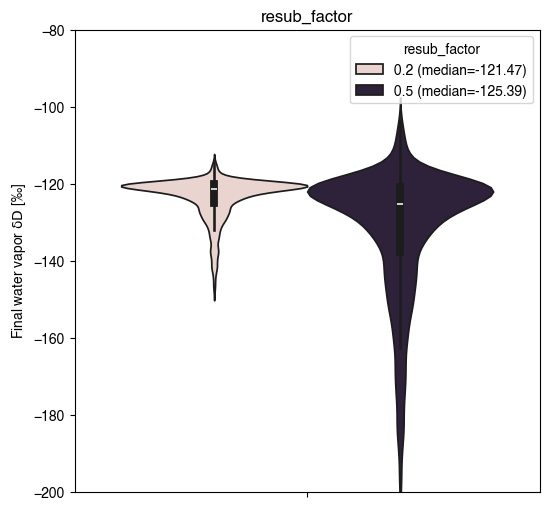

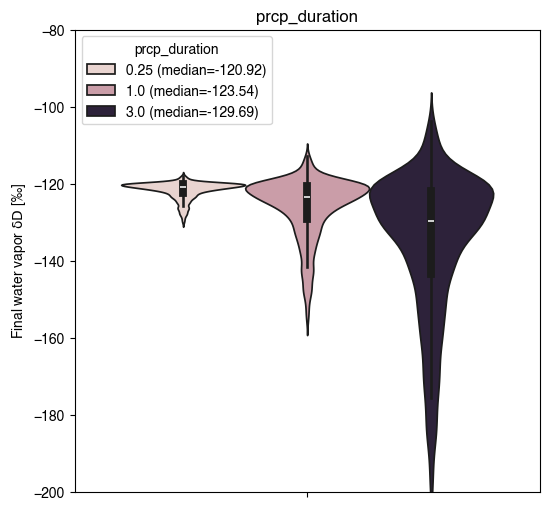

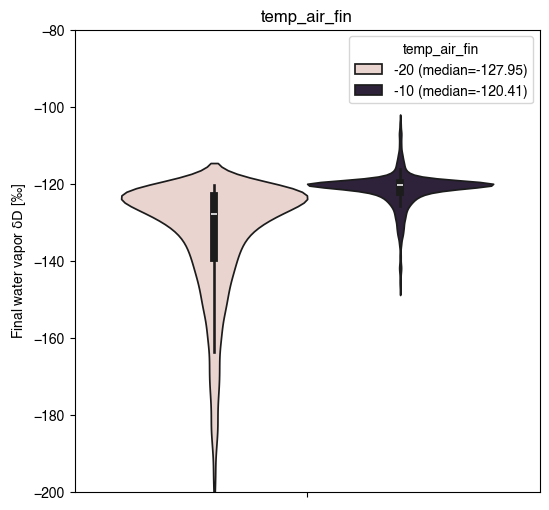

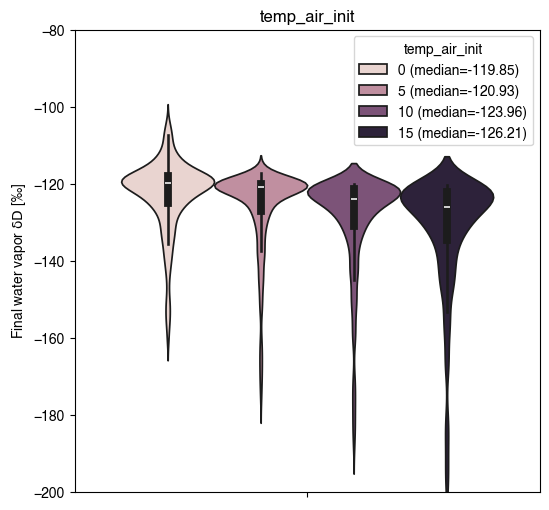

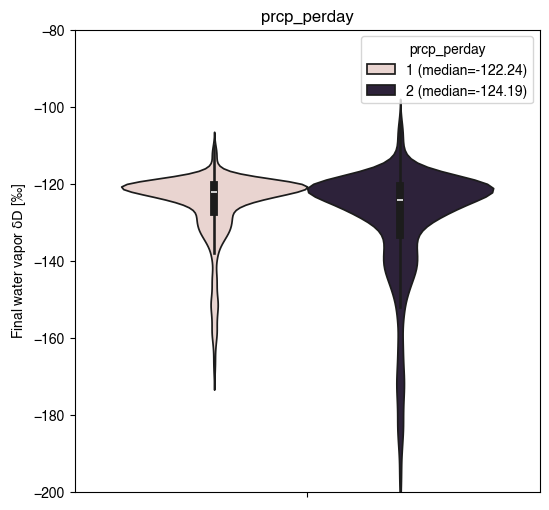

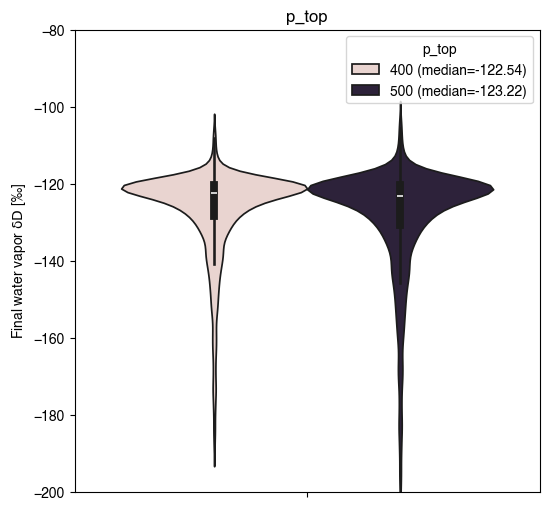

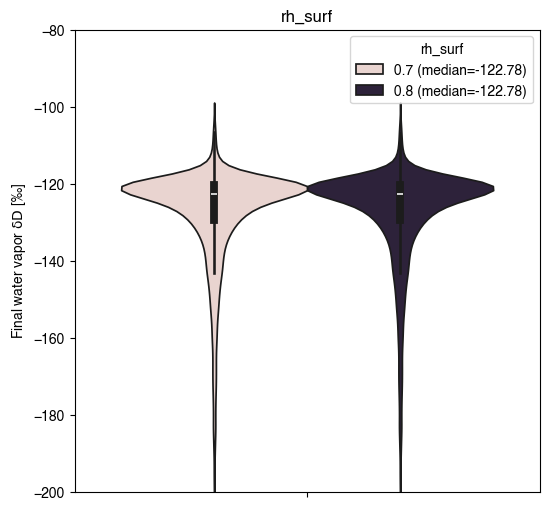

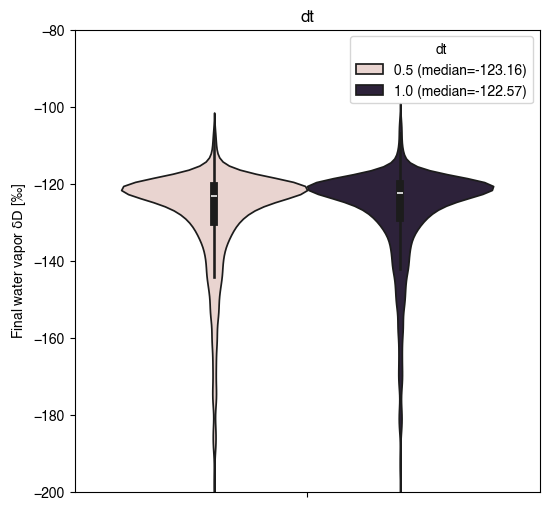

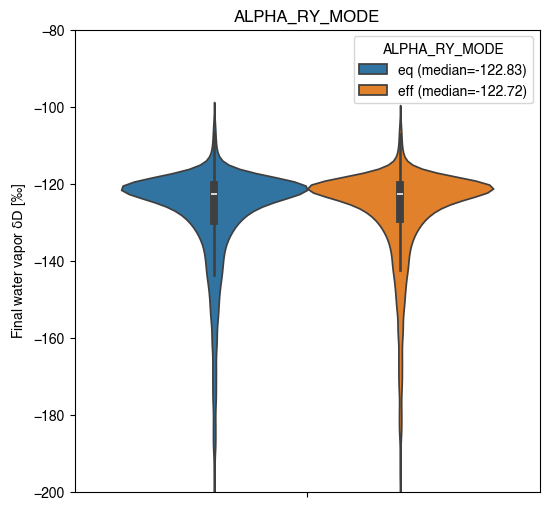

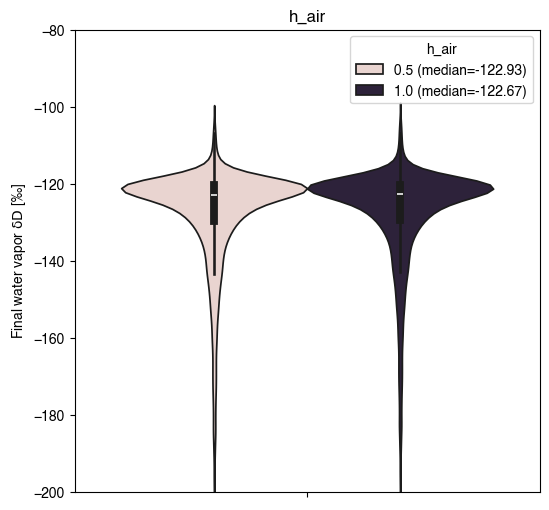

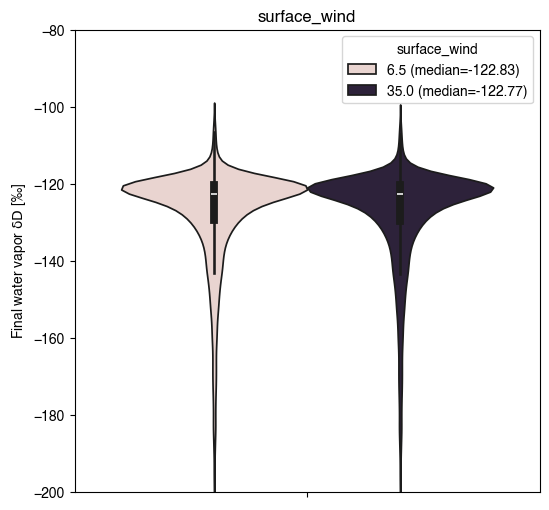

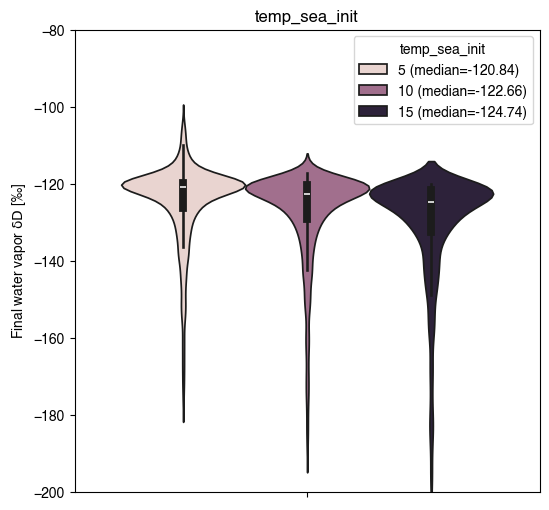

,anom_abs_HDO
prcp_duration,8.770816
temp_air_fin,7.539001
temp_air_init,6.357621
resub_factor,3.926228
temp_sea_init,3.902495
prcp_perday,1.946896
p_top,0.681347
dt,0.582911
h_air,0.261379
ALPHA_RY_MODE,0.117553


In [20]:
mean_dict_HDO = check_sensitivity(df_merged, param_fix_dict=param_fix_dict, ISO_TYPE="HDO", SHOW_FIG=True)
display(compute_mean_anom_ranking(mean_dict_HDO, "HDO"))

In [21]:
mean_dict_H218O = check_sensitivity(df_merged, param_fix_dict=param_fix_dict, ISO_TYPE="H218O", SHOW_FIG=False)
display(compute_mean_anom_ranking(mean_dict_H218O, "H218O"))

,anom_abs_H218O
prcp_duration,0.646037
temp_air_fin,0.603958
temp_air_init,0.396543
temp_sea_init,0.283198
resub_factor,0.268619
h_air,0.174533
prcp_perday,0.131927
surface_wind,0.096526
p_top,0.044025
dt,0.037391


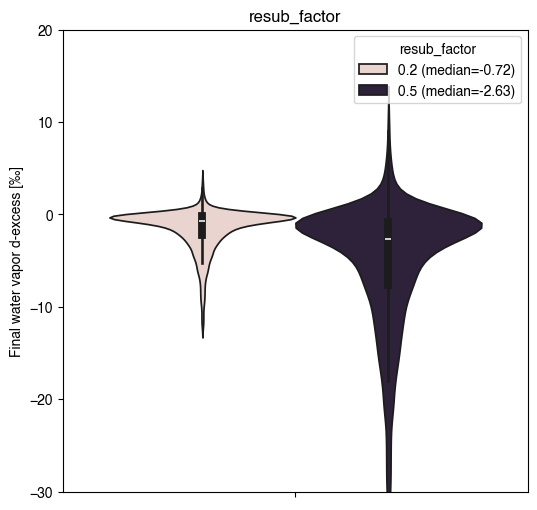

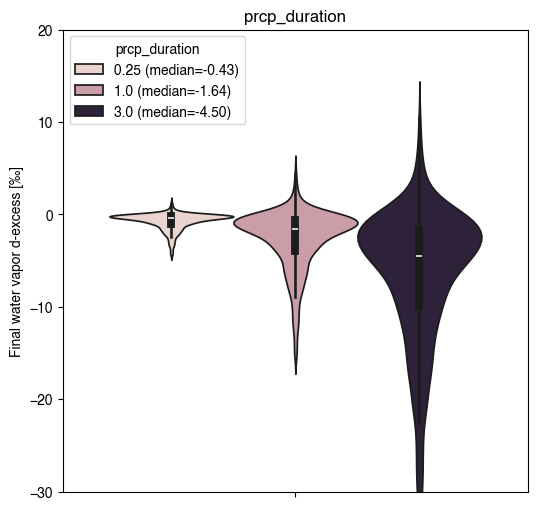

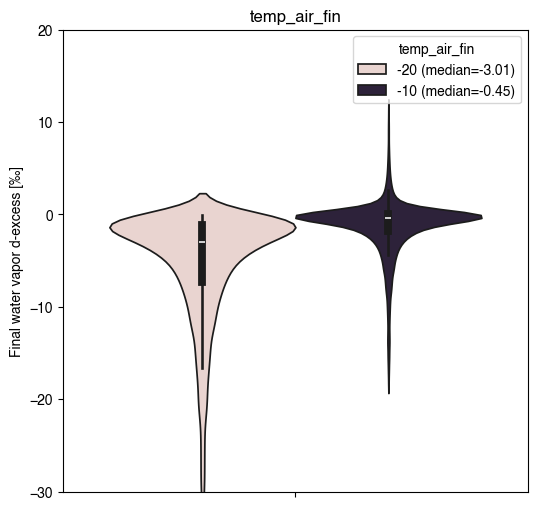

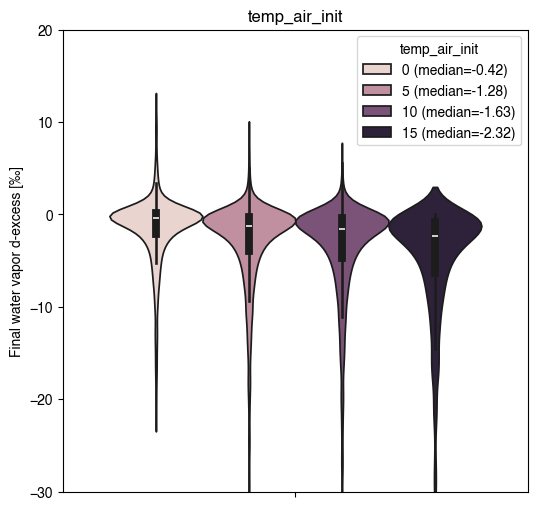

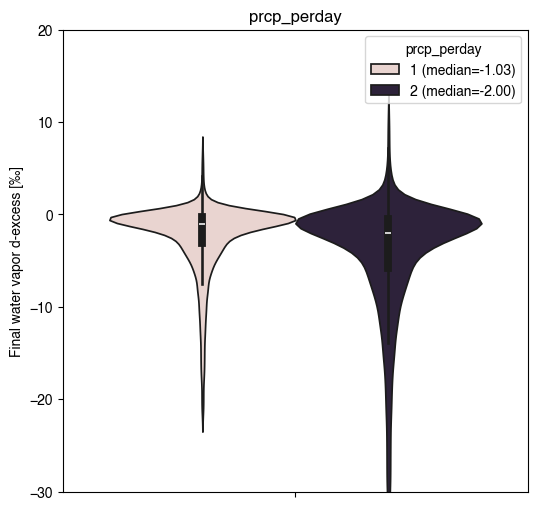

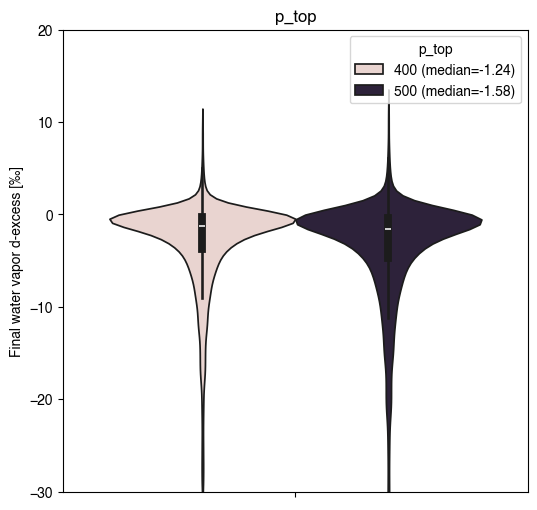

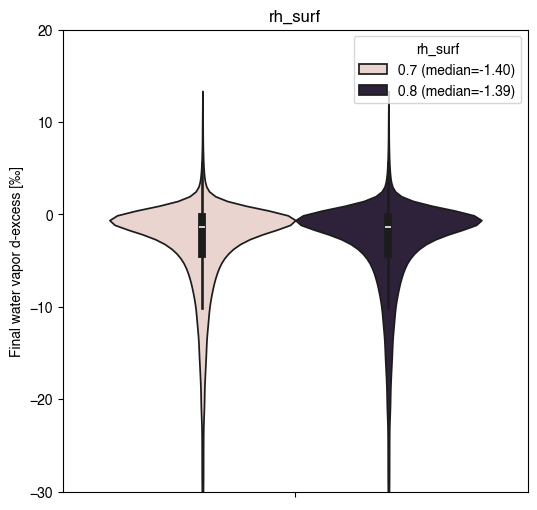

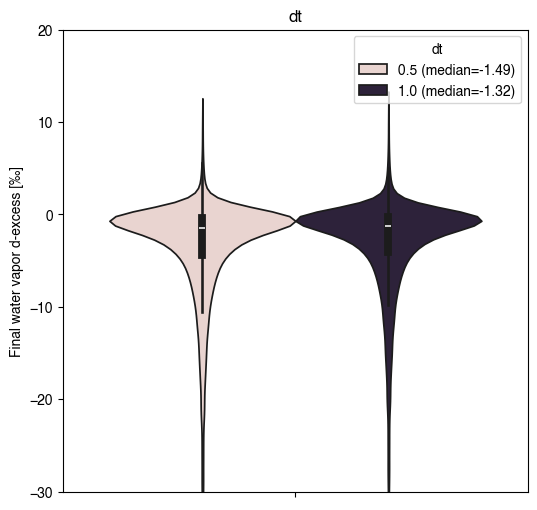

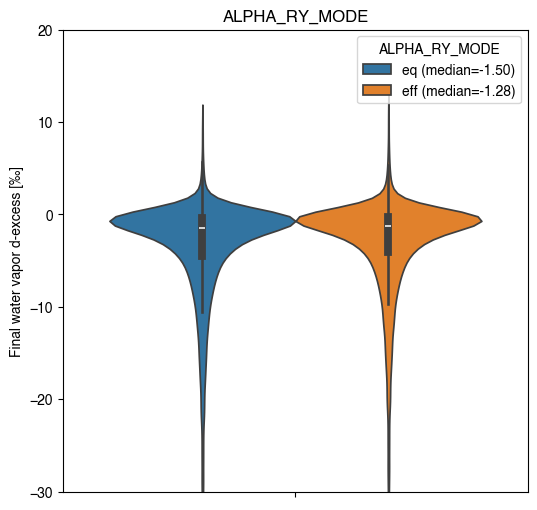

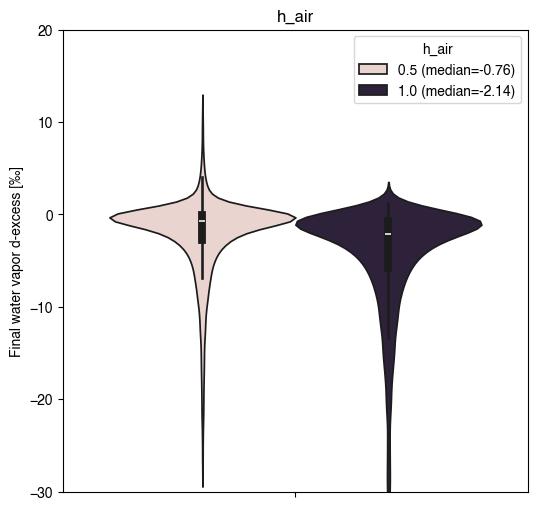

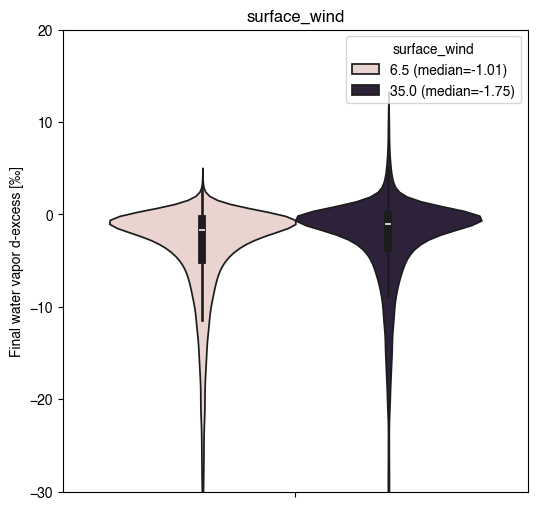

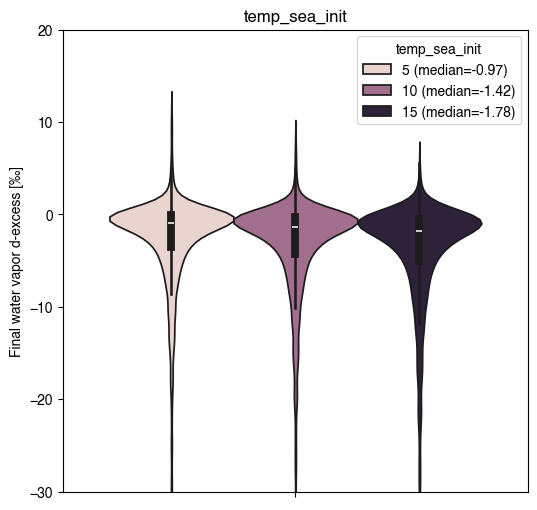

,anom_abs_dex
prcp_duration,4.073621
temp_air_fin,2.562437
resub_factor,1.908029
temp_air_init,1.897238
h_air,1.378084
prcp_perday,0.974735
temp_sea_init,0.807453
surface_wind,0.742789
p_top,0.338489
ALPHA_RY_MODE,0.216179


In [22]:
mean_dict_dex = check_sensitivity(df_merged, param_fix_dict=param_fix_dict, ISO_TYPE="dex", SHOW_FIG=True)
display(compute_mean_anom_ranking(mean_dict_dex, "dex"))

## plot sensitive parameters

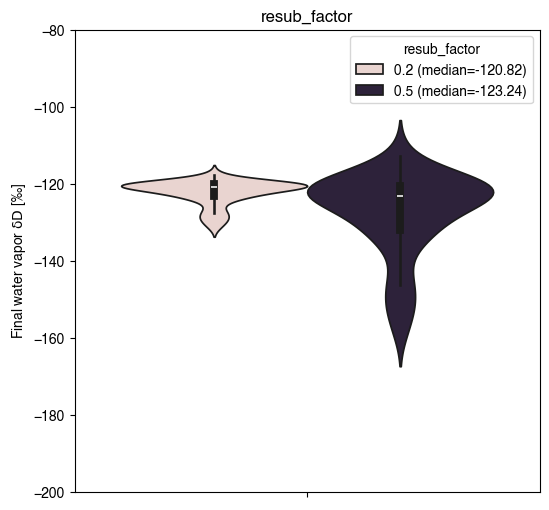

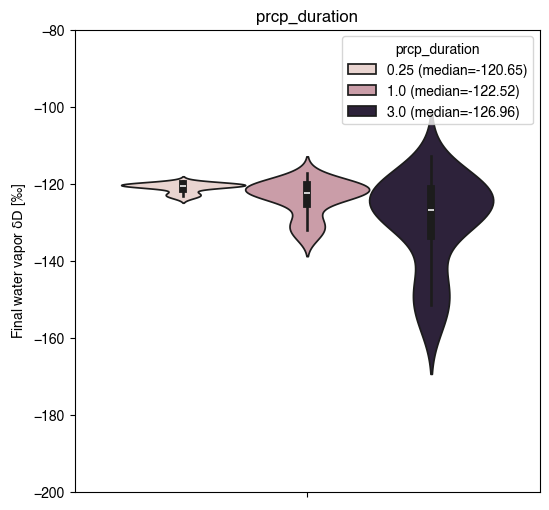

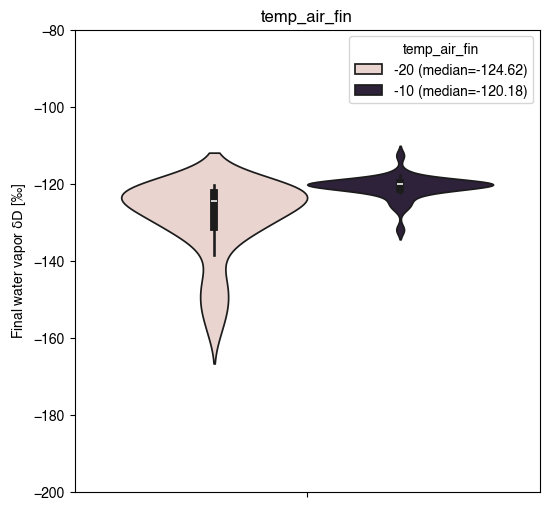

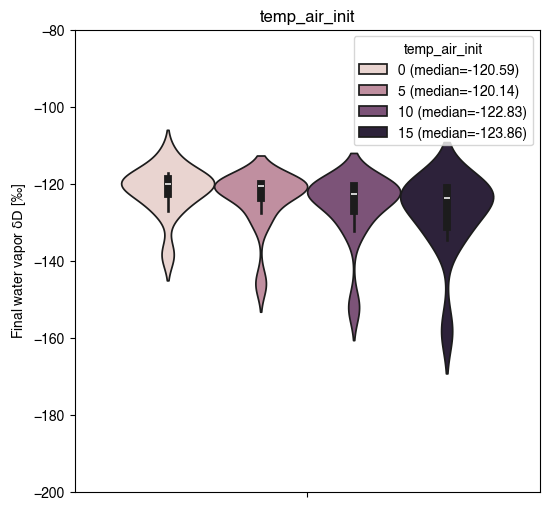

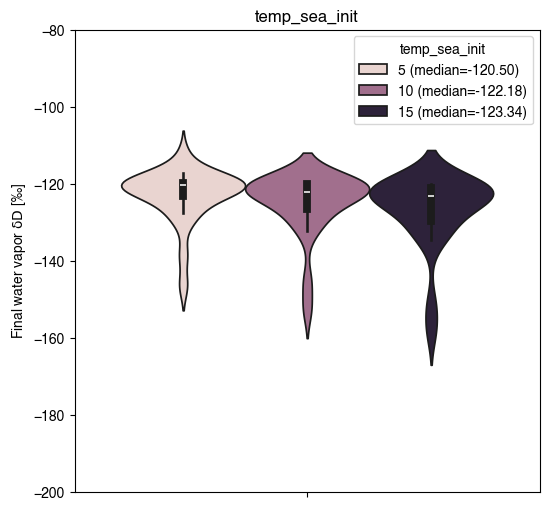

,anom_abs_HDO
prcp_duration,6.303773
temp_air_fin,4.439430
temp_air_init,3.270825
temp_sea_init,2.847075
resub_factor,2.418525


In [23]:
mean_dict_dD_sel = check_sensitivity(df_merged, param_fix_dict=param_fix_dict,
                              ISO_TYPE="HDO", ALL_PARAM=False)
compute_mean_anom_ranking(mean_dict_dD_sel, "HDO",  ALL_PARAM=False)

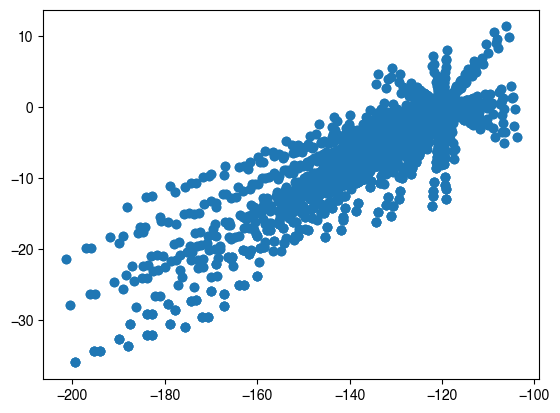

In [25]:
plt.scatter(df_merged["obs_fin_dD"],df_merged["obs_fin_dex"])